# Phase 1 — Preprocessing FD003

**Différences vs FD001 et FD002 :**

| | FD001 | FD002 | FD003 |
|--|-------|-------|-------|
| Conditions opérationnelles | 1 | 6 | 1 |
| Modes de panne | 1 | 1 | **2** |
| Moteurs train | 100 | 260 | 100 |
| Settings | supprimés | gardés | supprimés |

**FD003 = même condition que FD001 mais 2 modes de panne différents**

## 1. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print(' Imports OK')

 Imports OK


In [4]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/industrial-ai-platform'
DATA_DIR    = f'{BASE_DIR}/Data/cmapss'
OUTPUT_DIR  = f'{BASE_DIR}/preprocessing_FD003'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f'{DATA_DIR}/train_FD003.txt'
TEST_PATH  = f'{DATA_DIR}/test_FD003.txt'
RUL_PATH   = f'{DATA_DIR}/RUL_FD003.txt'

print(f' Chemins définis')
print(f'Output : {OUTPUT_DIR}')

Mounted at /content/drive
 Chemins définis
Output : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD003


## 2. Chargement des données

In [5]:
COLUMNS = [
    'unit_id', 'time_cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i:02d}' for i in range(1, 22)]
]

df_train = pd.read_csv(TRAIN_PATH, sep=r'\s+', header=None, names=COLUMNS)
df_test  = pd.read_csv(TEST_PATH,  sep=r'\s+', header=None, names=COLUMNS)
df_rul   = pd.read_csv(RUL_PATH,   header=None, names=['RUL_true'])

print(f'Train : {df_train.shape} | {df_train["unit_id"].nunique()} moteurs')
print(f'Test  : {df_test.shape}  | {df_test["unit_id"].nunique()} moteurs')
print(f'RUL ground truth : {len(df_rul)} valeurs')

Train : (24720, 26) | 100 moteurs
Test  : (16596, 26)  | 100 moteurs
RUL ground truth : 100 valeurs


## 3. Charger le feature config + vérifier les settings

In [6]:
with open(CONFIG_PATH) as f:
    config = json.load(f)

SENSORS_TO_KEEP = config['sensors_to_keep']
SENSORS_TO_DROP = config['sensors_to_drop']
RUL_CAP         = config['rul_cap']   # 125
WINDOW_SIZE     = 30

# Vérifier les settings de FD003
print('=== Settings opérationnels FD003 ===')
print(df_train[['op_setting_1','op_setting_2','op_setting_3']].std().round(6))
print('\n→ Si std ≈ 0 : supprimer (comme FD001)')
print('→ Si std > 0 : garder (comme FD002)')

=== Settings opérationnels FD003 ===
op_setting_1    0.002194
op_setting_2    0.000294
op_setting_3    0.000000
dtype: float64

→ Si std ≈ 0 : supprimer (comme FD001)
→ Si std > 0 : garder (comme FD002)


## 4. EDA rapide FD003

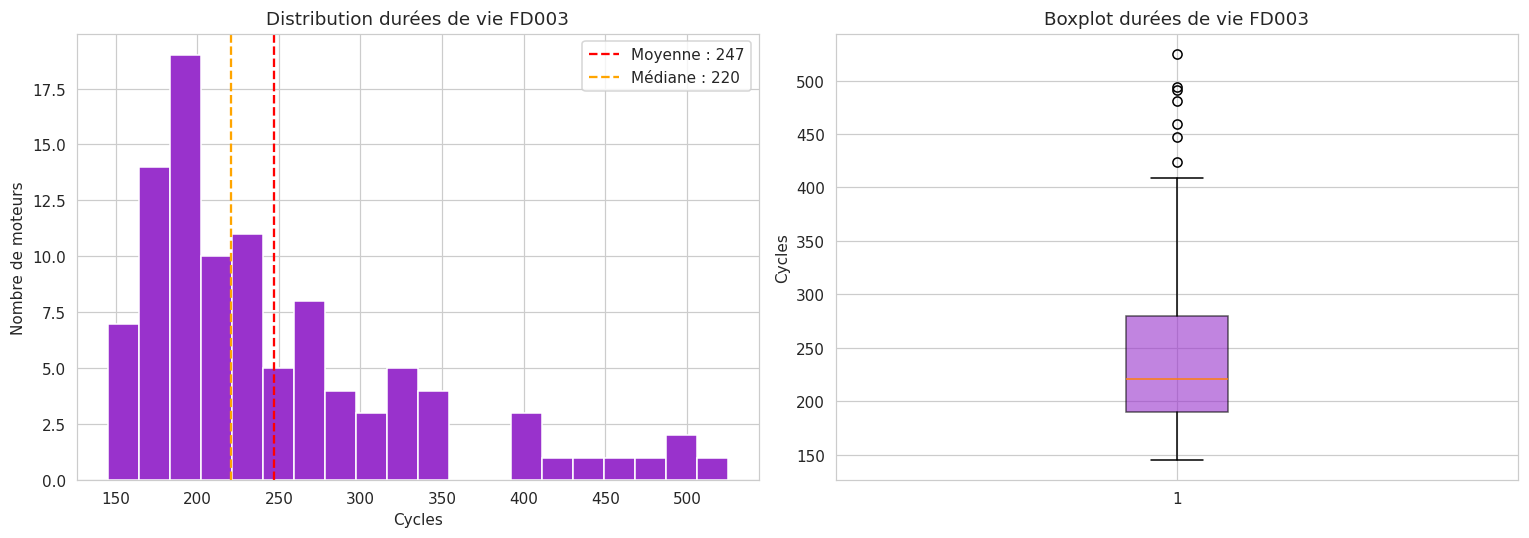


 Statistiques durées de vie FD003 :
count    100.0
mean     247.2
std       86.5
min      145.0
25%      189.8
50%      220.5
75%      279.8
max      525.0
Name: time_cycle, dtype: float64


In [8]:
# Distribution des durées de vie
lifetimes = df_train.groupby('unit_id')['time_cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lifetimes, bins=20, color='darkorchid', edgecolor='white')
axes[0].axvline(lifetimes.mean(),   color='red',    linestyle='--',
                label=f'Moyenne : {lifetimes.mean():.0f}')
axes[0].axvline(lifetimes.median(), color='orange', linestyle='--',
                label=f'Médiane : {lifetimes.median():.0f}')
axes[0].set_title('Distribution durées de vie FD003', fontsize=12)
axes[0].set_xlabel('Cycles')
axes[0].set_ylabel('Nombre de moteurs')
axes[0].legend()

axes[1].boxplot(lifetimes, patch_artist=True,
                boxprops=dict(facecolor='darkorchid', alpha=0.6))
axes[1].set_title('Boxplot durées de vie FD003', fontsize=12)
axes[1].set_ylabel('Cycles')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fd003_lifetime_distribution.png', bbox_inches='tight')
plt.show()

print('\n Statistiques durées de vie FD003 :')
print(lifetimes.describe().round(1))

In [9]:
# Comparaison FD001 vs FD003 — durées de vie
# FD003 a 2 modes de panne → durées de vie potentiellement différentes
print('=== Comparaison durées de vie ===')
print(f'FD001 : min=128  max=362  mean=206  std=46')
print(f'FD003 : min={lifetimes.min():.0f}  max={lifetimes.max():.0f}  '
      f'mean={lifetimes.mean():.0f}  std={lifetimes.std():.0f}')
print('\n→ Les 2 modes de panne de FD003 peuvent créer une distribution bimodale')

=== Comparaison durées de vie ===
FD001 : min=128  max=362  mean=206  std=46
FD003 : min=145  max=525  mean=247  std=86

→ Les 2 modes de panne de FD003 peuvent créer une distribution bimodale


## 5. Calcul RUL + Clipping

In [10]:
# RUL train
max_cycles = df_train.groupby('unit_id')['time_cycle'].max().rename('max_cycle')
df_train   = df_train.merge(max_cycles, on='unit_id')
df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycle']
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

# RUL test
test_max = df_test.groupby('unit_id')['time_cycle'].max().reset_index()
test_max.columns = ['unit_id', 'max_cycle_test']
df_test  = df_test.merge(test_max, on='unit_id')
df_rul['unit_id'] = range(1, len(df_rul) + 1)
df_test  = df_test.merge(df_rul, on='unit_id')
df_test['RUL'] = df_test['RUL_true'] + (df_test['max_cycle_test'] - df_test['time_cycle'])
df_test['RUL'] = df_test['RUL'].clip(upper=RUL_CAP)

pct = (df_train['RUL'] == RUL_CAP).mean() * 100
print(f' RUL calculé et plafonné à {RUL_CAP}')
print(f'{pct:.1f}% des lignes plafonnées à {RUL_CAP}')

 RUL calculé et plafonné à 125
49.4% des lignes plafonnées à 125


## 6. Feature Selection
**FD003 = 1 condition opérationnelle → settings supprimés comme FD001**

In [11]:
SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# FD003 a 1 condition → settings constants → supprimés
COLS_TO_DROP = SENSORS_TO_DROP + SETTING_COLS + ['max_cycle', 'max_cycle_test', 'RUL_true']

df_train = df_train.drop(columns=[c for c in COLS_TO_DROP if c in df_train.columns])
df_test  = df_test.drop(columns=[c for c in COLS_TO_DROP if c in df_test.columns])

FEATURE_COLS = SENSORS_TO_KEEP  # 14 capteurs — comme FD001
N_FEATURES   = len(FEATURE_COLS)

print(f'Feature cols ({N_FEATURES}) : {FEATURE_COLS}')
print(f'Shape train : {df_train.shape}')
print(f'Shape test  : {df_test.shape}')
print('\n💡 Settings supprimés — FD003 a 1 seule condition (comme FD001)')

Feature cols (14) : ['sensor_02', 'sensor_03', 'sensor_04', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Shape train : (24720, 17)
Shape test  : (16596, 17)

💡 Settings supprimés — FD003 a 1 seule condition (comme FD001)


## 7. Normalisation — Scaler Global

In [12]:
scaler = MinMaxScaler(feature_range=(0, 1))

df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

joblib.dump(scaler, f'{OUTPUT_DIR}/minmax_scaler_FD003.pkl')

print(' Scaler global appliqué et sauvegardé')
print('\nPlage après normalisation (train) :')
print(df_train[FEATURE_COLS].agg(['min','max']).T.round(3).head(5))

 Scaler global appliqué et sauvegardé

Plage après normalisation (train) :
           min  max
sensor_02  0.0  1.0
sensor_03  0.0  1.0
sensor_04  0.0  1.0
sensor_07  0.0  1.0
sensor_08  0.0  1.0


## 8. Fenêtres Glissantes (Window Size = 30)

In [13]:
def create_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            pad_y  = np.repeat(labels[0], window_size - T)
            labels = np.concatenate([pad_y, labels])
            T = window_size
        for t in range(T - window_size + 1):
            X_list.append(data[t : t + window_size])
            y_list.append(labels[t + window_size - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_test_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([np.repeat(labels[0], window_size - T), labels])
        X_list.append(data[-window_size:])
        y_list.append(labels[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


print(f'Création des fenêtres (W={WINDOW_SIZE})...')
X_train_full, y_train_full = create_sequences(df_train, FEATURE_COLS, WINDOW_SIZE)
X_test,       y_test       = create_test_sequences(df_test, FEATURE_COLS, WINDOW_SIZE)

print(f' X_train_full : {X_train_full.shape}')
print(f' X_test       : {X_test.shape}')
print(f' y_train_full : {y_train_full.shape}')
print(f' y_test       : {y_test.shape}')

Création des fenêtres (W=30)...
 X_train_full : (21820, 30, 14)
 X_test       : (100, 30, 14)
 y_train_full : (21820,)
 y_test       : (100,)


## 9. Sauvegarder unit_ids + fichiers .npy

In [14]:
max_cycles_raw = df_train.groupby('unit_id')['time_cycle'].max()
unit_ids_per_seq = []
for uid, cnt in max_cycles_raw.items():
    n_seq = max(cnt - WINDOW_SIZE + 1, 1)
    unit_ids_per_seq.extend([uid] * n_seq)
unit_ids_per_seq = np.array(unit_ids_per_seq)

np.save(f'{OUTPUT_DIR}/X_train.npy',        X_train_full)
np.save(f'{OUTPUT_DIR}/y_train.npy',        y_train_full)
np.save(f'{OUTPUT_DIR}/X_test.npy',         X_test)
np.save(f'{OUTPUT_DIR}/y_test.npy',         y_test)
np.save(f'{OUTPUT_DIR}/unit_ids_train.npy', unit_ids_per_seq)

print('Fichiers sauvegardés :')
for name in ['X_train', 'y_train', 'X_test', 'y_test', 'unit_ids_train']:
    path = f'{OUTPUT_DIR}/{name}.npy'
    size = os.path.getsize(path) / 1024
    print(f'  {name}.npy  →  {size:.1f} KB')

Fichiers sauvegardés :
  X_train.npy  →  35798.6 KB
  y_train.npy  →  85.4 KB
  X_test.npy  →  164.2 KB
  y_test.npy  →  0.5 KB
  unit_ids_train.npy  →  170.6 KB


## 10. Sauvegarder le config FD003

In [15]:
config_fd003 = {
    'dataset':           'FD003',
    'sensors_to_keep':   SENSORS_TO_KEEP,
    'sensors_to_drop':   SENSORS_TO_DROP,
    'feature_cols':      FEATURE_COLS,
    'n_features':        N_FEATURES,
    'window_size':       WINDOW_SIZE,
    'rul_cap':           RUL_CAP,
    'n_train_engines':   df_train['unit_id'].nunique(),
    'n_test_engines':    df_test['unit_id'].nunique(),
    'operating_conditions': 1,
    'fault_modes':       2,
    'scaler':            'global_minmax',
    'note':              'Settings supprimés (1 condition) — 2 modes de panne'
}

with open(f'{OUTPUT_DIR}/config_FD003.json', 'w') as f:
    json.dump(config_fd003, f, indent=2)

print(' Config FD003 sauvegardé')
print(json.dumps(config_fd003, indent=2))

 Config FD003 sauvegardé
{
  "dataset": "FD003",
  "sensors_to_keep": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "sensors_to_drop": [
    "sensor_01",
    "sensor_05",
    "sensor_06",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
  ],
  "feature_cols": [
    "sensor_02",
    "sensor_03",
    "sensor_04",
    "sensor_07",
    "sensor_08",
    "sensor_09",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "n_features": 14,
  "window_size": 30,
  "rul_cap": 125,
  "n_train_engines": 100,
  "n_test_engines": 100,
  "operating_conditions": 1,
  "fault_modes": 2,
  "scaler": "global_minmax",
  "note": "Settings supprim\u00e9s (1 condition) \u2014 2 modes de panne"
}


## 11. Résumé Final

In [16]:
print('=' * 55)
print(' RÉSUMÉ PREPROCESSING FD003')
print('=' * 55)
print(f'Moteurs train         : {df_train["unit_id"].nunique()}')
print(f'Moteurs test          : {df_test["unit_id"].nunique()}')
print(f'Features              : {N_FEATURES} capteurs')
print(f'Window size           : {WINDOW_SIZE}')
print(f'RUL cap               : {RUL_CAP}')
print(f'X_train shape         : {X_train_full.shape}')
print(f'X_test shape          : {X_test.shape}')
print(f'Conditions opérat.    : 1 (comme FD001)')
print(f'Modes de panne        : 2 (différent de FD001!)')
print(f'Scaler                : Global MinMax')
print(f'Settings              : supprimés (constants)')
print('=' * 55)
print(f'\n Preprocessing FD003 terminé !')
print(f' Fichiers dans : {OUTPUT_DIR}')


 RÉSUMÉ PREPROCESSING FD003
Moteurs train         : 100
Moteurs test          : 100
Features              : 14 capteurs
Window size           : 30
RUL cap               : 125
X_train shape         : (21820, 30, 14)
X_test shape          : (100, 30, 14)
Conditions opérat.    : 1 (comme FD001)
Modes de panne        : 2 (différent de FD001!)
Scaler                : Global MinMax
Settings              : supprimés (constants)

 Preprocessing FD003 terminé !
 Fichiers dans : /content/drive/MyDrive/industrial-ai-platform/preprocessing_FD003
